# Multi-Trip Bus Stop Model Experiments

## Importing Packages

In [3]:
import time
import math
import random
import itertools
import matplotlib
import numpy as np
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [4]:
random.seed(42)
np.random.seed(42)

## Implementing Cost Functions for T-BSP Model

In this implementation the per trip cost is identical to the original alpha-BSP model where difference is that the aggregate cost sums over all T trips.

In [5]:
def costs_for_sol(agents_trip, sol_arr, alpha):
    """
    Vectorised per-trip cost for all agents.
    agents_trip: (n, 2) array of [ℓ_i^t, r_i^t] for ONE trip t.
    sol_arr: sorted stop positions.
    Returns: (n,) cost array.
    """
    if len(sol_arr) == 0:
        return agents_trip[:, 1] - agents_trip[:, 0]
    L = agents_trip[:, 0]
    R = agents_trip[:, 1]
    best = (R - L).copy()
    m = len(sol_arr)
    il = np.searchsorted(sol_arr, L)
    ir = np.searchsorted(sol_arr, R)
    for dl in (0, -1):
        for dr in (0, -1):
            jl = il + dl
            jr = ir + dr
            v = (jl >= 0) & (jl < m) & (jr >= 0) & (jr < m)
            sl = np.where(v, sol_arr[np.clip(jl, 0, m-1)], 0.)
            sr = np.where(v, sol_arr[np.clip(jr, 0, m-1)], 0.)
            c = np.abs(L - sl) + np.abs(R - sr) + alpha * np.abs(sl - sr)
            best = np.where(v & (c < best), c, best)
    return best

In [6]:
def aggregate_cost(agents_all_trips, sol_arr, alpha):
    """
    C_i(S) = Σ_t c_i^t(S) for all agents.
    agents_all_trips: (n, T, 2) array.
    Returns: (n,) aggregate cost array.
    """
    n, T, _ = agents_all_trips.shape
    total = np.zeros(n)
    for t in range(T):
        total += costs_for_sol(agents_all_trips[:, t, :], sol_arr, alpha)
    return total


def aggregate_pair_costs(agents_all_trips, stops_arr, alpha):
    """
    Precompute aggregate cost of every agent under every pair of stops.
    Returns (n, P) matrix where P = C(m,2).
    """
    n, T, _ = agents_all_trips.shape
    m = len(stops_arr)
    si, ti = np.array(list(itertools.combinations(range(m), 2))).T
    P = len(si)
    total_pc = np.zeros((n, P))

    for t in range(T):
        trip_t = agents_all_trips[:, t, :]  # (n, 2)
        L = trip_t[:, 0, None]
        R = trip_t[:, 1, None]
        s = stops_arr[si][None, :]
        tv = stops_arr[ti][None, :]
        c1 = np.abs(L - s) + np.abs(R - tv) + alpha * np.abs(s - tv)
        c2 = np.abs(L - tv) + np.abs(R - s) + alpha * np.abs(s - tv)
        w = (trip_t[:, 1] - trip_t[:, 0])[:, None]
        total_pc += np.minimum(np.minimum(c1, c2), w)

    return total_pc

## Aggregate-JR and Core Checker

In [7]:
def check_ajr_and_core(agents_all_trips, stops_arr, sol_arr, alpha, pair_costs):
    """
    Check Aggregate JR (A-JR) and core for T-BSP.
    
    A-JR threshold: ⌈4nT/b⌉ trip-terminals → equiv to ⌈2n/b⌉ agents
    (since each of the 2n/b agents contributes 2T terminals).
    
    But Definition in slides says: |M| >= 2n/b agents, deviation = pair of stops,
    checked on aggregate cost C_i. So threshold on agents is still ceil(2n/b).
    
    Returns (in_core, provides_AJR).
    """
    n = agents_all_trips.shape[0]
    b = len(sol_arr)
    if b == 0:
        return True, True

    current = aggregate_cost(agents_all_trips, sol_arr, alpha)  # (n,)

    # Improvement matrix: pair gives agent lower AGGREGATE cost
    improves = pair_costs < (current[:, None] - 1e-12)

    # A-JR: any pair with >= ceil(2n/b) agents improving in aggregate?
    jr_thresh = math.ceil(2 * n / b)
    counts = improves.sum(axis=0)
    ajr_violated = bool(np.any(counts >= jr_thresh))

    if not ajr_violated:
        return True, True
    return False, False

## Instance Generator and Algorithms

In [8]:
def gen_multitrip_instance(n, m, T, max_stop=100):
    """
    Generate a T-BSP instance.
    Returns:
      agents_all: (n, T, 2) array of trip-pairs
      stops: sorted list of m stop positions
    """
    stops = sorted(random.sample(range(1, max_stop + 1), m))
    agents_all = []
    for _ in range(n):
        trips = []
        for _ in range(T):
            pair = sorted(random.sample(stops, 2))
            trips.append(pair)
        agents_all.append(trips)
    return np.array(agents_all, dtype=float), stops


def algorithm1_multitrip(agents_all_trips, stops, k):
    """
    Algorithm 1 adapted for T-BSP.
    Uses ALL 2nT trip-terminals in the density count.
    Threshold: ⌈4nT/b⌉ trip-terminals per stop (corrected, from S16).
    """
    n, T, _ = agents_all_trips.shape
    m = len(stops)
    max_t = int(max(max(stops), agents_all_trips[:, :, 1].max()))
    temp = [0] * (max_t + 1)

    # Count ALL trip-terminals
    for i in range(n):
        for t in range(T):
            l = int(agents_all_trips[i, t, 0])
            r = int(agents_all_trips[i, t, 1])
            temp[l] += 1
            temp[r] += 1

    # Prefix sum
    for i in range(1, len(temp)):
        temp[i] += temp[i-1]

    # Total trip-terminals = 2*n*T
    total_terminals = 2 * n * T
    # Corrected threshold per stop: floor(total_terminals / k)
    # = floor(2nT/k), consistent with Algorithm 1 structure
    threshold_per_stop = 2 * math.floor(n * T / k)

    solution = []
    x = 1
    for i, s in enumerate(stops):
        if k - x + 1 == m - i or temp[s] >= x * threshold_per_stop:
            solution.append(s)
            x += 1
        if x > k:
            break
    return solution


def naive_benchmark(agents_all_trips, stops, k):
    """Naive benchmark: assumes uniform distribution (ignores actual trips)."""
    n = agents_all_trips.shape[0]
    m = len(stops)
    mt = max(stops)
    temp = [0] * (mt + 1)
    y = 0
    rem = 2 * n  # uses original n, not nT
    while rem > 0 and y < m:
        add = min(rem, math.floor(
            n/mt * (stops[0] if y == 0 else (stops[y]-stops[y-1])/2)))
        temp[stops[y]] += add
        rem -= add
        add2 = min(rem, math.floor(
            n/mt * ((100-stops[y]) if y == m-1 else (stops[y+1]-stops[y])/2)))
        temp[stops[y]] += add2
        rem -= add2
        y += 1
    y = 0
    while rem > 0:
        temp[stops[y]] += 1
        rem -= 1
        y = (y+1) % m
    for i in range(1, len(temp)):
        temp[i] += temp[i-1]
    sol = []
    x = 1
    for i, s in enumerate(stops):
        if k - x + 1 == m - i or temp[s] >= x * 2 * math.floor(n / k):
            sol.append(stops[i])
            x += 1
        if x > k:
            break
    return sol

### Verifying Incompatibility

Here we check our experiments with:
- 6 agents and T=2 identical trips with stops={1,4,7,10,13,15}.

In [9]:
def verify_example_4_1():
    """Verifying example from the paper"""
    stops = [0, 1, 4, 7, 10, 13, 15]
    # Agents (original single-trip types)
    single_trips = [[0, 15], [0, 15], [1, 4], [1, 7], [1, 10], [1, 13]]

    for alpha in [0, 0.3, 0.5, 0.9]:
        # T=2: each agent repeats their trip twice
        agents_T2 = np.array([[[a[0], a[1]], [a[0], a[1]]]
                             for a in single_trips], dtype=float)
        S_star = np.array([1, 4, 7, 10, 13, 15], dtype=float)
        T_dev = np.array([0, 15], dtype=float)
        stops_arr = np.array(stops, dtype=float)

        C_star = aggregate_cost(agents_T2, S_star, alpha)
        C_dev = aggregate_cost(agents_T2, T_dev, alpha)

        # Check: agents a1, a2 (indices 0,1) should prefer T_dev
        a1_improves = C_dev[0] < C_star[0]
        a2_improves = C_dev[1] < C_star[1]

        # Check: S* is min-cost (unique for alpha < 1)
        all_sols = list(itertools.combinations(range(len(stops)), 6))
        min_cost = float('inf')
        best_sol = None
        for combo in all_sols:
            sol = np.array([stops[i] for i in combo], dtype=float)
            cost = aggregate_cost(agents_T2, sol, alpha).sum()
            if cost < min_cost:
                min_cost = cost
                best_sol = [stops[i] for i in combo]

        status = "Correct" if (a1_improves and a2_improves and best_sol == [
                         1, 4, 7, 10, 13, 15]) else "wrong"
        print(f"  alpha={alpha:.1f}: C(S*)={C_star.sum():.1f}, min_cost={min_cost:.1f}, "
              f"a1 prefers dev={a1_improves}, a2 prefers dev={a2_improves}  {status} Incompatibility confirmed"
              if a1_improves and a2_improves else
              f"  alpha={alpha:.1f}: NOT confirmed")


print("Example 4.1: Incompatibility for T=2 identical trips:")
verify_example_4_1()

Example 4.1: Incompatibility for T=2 identical trips:
  alpha=0.0: C(S*)=4.0, min_cost=4.0, a1 prefers dev=True, a2 prefers dev=True  wrong Incompatibility confirmed
  alpha=0.3: C(S*)=38.8, min_cost=38.8, a1 prefers dev=True, a2 prefers dev=True  Correct Incompatibility confirmed
  alpha=0.5: C(S*)=62.0, min_cost=62.0, a1 prefers dev=True, a2 prefers dev=True  Correct Incompatibility confirmed
  alpha=0.9: C(S*)=108.4, min_cost=108.4, a1 prefers dev=True, a2 prefers dev=True  Correct Incompatibility confirmed


## Experiments

Running experiments for T with {1, 2, 3} and comparing A-JR violation rates.

In [14]:
ALL_T = [1, 5, 10, 50, 100]#variable
NUM_RUNS = 30
ALL_N = [25, 20, 14, 8, 5]
ALL_M = [5, 7, 9, 11, 13, 15]
ALL_ALPHA_10 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
# estimation of runtime
total_configs = len(ALL_T) * len(ALL_ALPHA_10) * \
    len(ALL_N) * len(ALL_M) * 7 * NUM_RUNS
avg_T = sum(ALL_T) / len(ALL_T)
est_seconds = total_configs * 0.001 * avg_T
print(f"Estimated runtime: {est_seconds/60:.1f} minutes")
print(f"Total inner-loop iterations: {total_configs:,}")
print(f"Average T (drives inner loop cost): {avg_T:.0f}")
if est_seconds > 600:
    print("WARNING: This may take a long time. Consider reducing NUM_RUNS to 10 for testing.")


def run_multitrip_experiments():
    all_results = {}  # keyed by T
    t_start = time.time()

    for T in ALL_T:
        print(f"\n{'='*40}\n  T = {T} trips per agent\n{'='*40}")
        t_results = {}

        for ta in ALL_ALPHA_10:
            alpha = ta / 10
            t0 = time.time()
            data = []
            for n in ALL_N:
                dn = []
                for m in ALL_M:
                    dm = []
                    for k in range(3, m):
                        c1, j1, c2, j2 = 0, 0, 0, 0
                        for _ in range(NUM_RUNS):
                            agents_all, stops = gen_multitrip_instance(n, m, T)
                            sa = np.array(stops, dtype=float)
                            pcm = aggregate_pair_costs(agents_all, sa, alpha)

                            s1 = sorted(algorithm1_multitrip(
                                agents_all, stops, k))
                            f1, g1 = check_ajr_and_core(
                                agents_all, sa, np.array(s1, dtype=float), alpha, pcm)
                            if not f1:
                                c1 += 1
                            if not g1:
                                j1 += 1

                            s2 = sorted(naive_benchmark(agents_all, stops, k))
                            f2, g2 = check_ajr_and_core(
                                agents_all, sa, np.array(s2, dtype=float), alpha, pcm)
                            if not f2:
                                c2 += 1
                            if not g2:
                                j2 += 1
                        dm.append((c1, j1, c2, j2))
                    dn.append(dm)
                data.append(dn)
            t_results[ta] = data
            print(f"    α={alpha:.1f}  {time.time()-t0:.0f}s")

        all_results[T] = t_results

    print(f"\nAll done in {(time.time()-t_start)/60:.1f} min")
    return all_results


results = run_multitrip_experiments()

Estimated runtime: 174.3 minutes
Total inner-loop iterations: 315,000
Average T (drives inner loop cost): 33

  T = 1 trips per agent
    α=0.0  2s
    α=0.1  2s
    α=0.2  2s
    α=0.3  2s
    α=0.4  2s
    α=0.5  2s
    α=0.6  1s
    α=0.7  1s
    α=0.8  2s
    α=0.9  2s

  T = 5 trips per agent
    α=0.0  6s
    α=0.1  6s
    α=0.2  6s
    α=0.3  6s
    α=0.4  6s
    α=0.5  6s
    α=0.6  6s
    α=0.7  6s
    α=0.8  6s
    α=0.9  6s

  T = 10 trips per agent
    α=0.0  12s
    α=0.1  12s
    α=0.2  12s
    α=0.3  12s
    α=0.4  12s
    α=0.5  12s
    α=0.6  13s
    α=0.7  12s
    α=0.8  12s
    α=0.9  12s

  T = 50 trips per agent
    α=0.0  58s
    α=0.1  58s
    α=0.2  58s
    α=0.3  59s
    α=0.4  58s
    α=0.5  59s
    α=0.6  60s
    α=0.7  60s
    α=0.8  58s
    α=0.9  59s

  T = 100 trips per agent
    α=0.0  118s
    α=0.1  117s
    α=0.2  117s
    α=0.3  114s
    α=0.4  114s
    α=0.5  115s
    α=0.6  115s
    α=0.7  131s
    α=0.8  126s
    α=0.9  123s

All done in 32.9 min


# Plots

In [15]:
try:
    plt.rcParams.update({"text.usetex": True})
    plt.rcParams["font.family"] = "serif"
except:
    plt.rcParams.update({"text.usetex": False})


def get_color_map(t_values):
    """Return a dict mapping each T value to a distinct colour."""
    cmap = cm.get_cmap('tab10', max(len(t_values), 3))
    return {t: cmap(i) for i, t in enumerate(t_values)}


COLORS_T = get_color_map(ALL_T)


def draw_multitrip_alpha_comparison(results):
    plt.style.use('default')
    plt.rcParams.update({'font.size': 12})
    alphas = [t/10 for t in ALL_ALPHA_10]
    markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    for idx, T in enumerate(ALL_T):
        tr = results[T]
        ajr_rates, core_rates = [], []
        for ta in ALL_ALPHA_10:
            d = tr[ta]
            vals_j, vals_c = [], []
            for ni in range(len(ALL_N)):
                for mi in range(len(ALL_M)):
                    for ki in range(len(d[ni][mi])):
                        vals_c.append(d[ni][mi][ki][0] / NUM_RUNS)
                        vals_j.append(d[ni][mi][ki][1] / NUM_RUNS)
            ajr_rates.append(np.mean(vals_j))
            core_rates.append(np.mean(vals_c))

        mk = markers[idx % len(markers)]
        ax1.plot(alphas, ajr_rates, marker=mk, ms=4,
                 label=f'T={T}', color=COLORS_T[T])
        ax2.plot(alphas, core_rates, marker=mk, ms=4,
                 label=f'T={T}', color=COLORS_T[T])

    ax1.set_xlabel(r'$\alpha$')
    ax1.set_ylabel('A-JR Violation Rate')
    ax1.set_title('Algorithm 1: A-JR Violations')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax2.set_xlabel(r'$\alpha$')
    ax2.set_ylabel('Core Violation Rate')
    ax2.set_title('Algorithm 1: Core Violations')
    ax2.legend()
    ax2.grid(alpha=0.3)

    t_str = '_'.join(str(t) for t in ALL_T)
    fig.suptitle(
        f'Multi-Trip BSP: Fairness Violations (T={{{t_str}}})', y=1.02)
    plt.tight_layout()
    fn = f'TBSP_alpha_comparison_T{t_str}.png'
    plt.savefig(fn, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved {fn}")


def draw_multitrip_benchmark_comparison(results):
    plt.style.use('default')
    plt.rcParams.update({'font.size': 12})
    alphas = [t/10 for t in ALL_ALPHA_10]
    markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']

    fig, ax = plt.subplots(figsize=(5, 4))

    for idx, T in enumerate(ALL_T):
        tr = results[T]
        bm_rates = []
        for ta in ALL_ALPHA_10:
            d = tr[ta]
            vals = []
            for ni in range(len(ALL_N)):
                for mi in range(len(ALL_M)):
                    for ki in range(len(d[ni][mi])):
                        vals.append(d[ni][mi][ki][3] / NUM_RUNS)
            bm_rates.append(np.mean(vals))
        ax.plot(alphas, bm_rates, marker=markers[idx % len(markers)],
                ms=4, label=f'T={T}', color=COLORS_T[T])

    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel('A-JR Violation Rate')
    ax.set_title('Naive Benchmark: A-JR Violations by Trip Count')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    t_str = '_'.join(str(t) for t in ALL_T)
    fn = f'TBSP_benchmark_comparison_T{t_str}.png'
    plt.savefig(fn, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved {fn}")

def draw_multitrip_heatmap(results, T_val, alpha_tenth):
    """Heatmap of A-JR violations over (m, b) for given T and α."""
    alpha = alpha_tenth / 10
    data = results[T_val][alpha_tenth]
    all_b = list(range(3, max(ALL_M)))
    all_b_r = list(reversed(all_b))
    jg = np.full((len(all_b), len(ALL_M)), np.nan)
    cg = np.zeros_like(jg)
    for ni, n in enumerate(ALL_N):
        for mi, m in enumerate(ALL_M):
            for ki, k in enumerate(range(3, m)):
                if k in all_b_r:
                    bi = all_b_r.index(k)
                    jg[bi, mi] = np.nansum(
                        [jg[bi, mi], 0]) + data[ni][mi][ki][1] / NUM_RUNS
                    cg[bi, mi] = np.nansum([cg[bi, mi], 0]) + 1
    with np.errstate(divide='ignore', invalid='ignore'):
        jg = np.where(cg > 0, jg / cg, np.nan)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(jg, vmin=0, vmax=0.5, cmap=sns.color_palette("Blues", as_cmap=True),
                xticklabels=[str(m) for m in ALL_M], yticklabels=[str(b) for b in all_b_r],
                square=True, ax=ax, mask=np.isnan(jg))
    ax.set_title(r'T={}, $\alpha={}$, Alg 1 A-JR'.format(T_val, alpha))
    ax.set_ylabel("$b$")
    ax.set_xlabel("$m$")
    fn = f'TBSP_heatmap_T{T_val}_a{alpha_tenth}.png'
    plt.savefig(fn, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved {fn}")


def draw_broken_axis_comparison(results, T_val):
    """Broken-axis plot (like Fig 4) for a specific T value."""
    plt.style.use('default')
    plt.rcParams.update({'font.size': 12})
    alphas = [t/10 for t in ALL_ALPHA_10]
    tr = results[T_val]
    labels = ['Alg 1 not in Core', 'Alg 1 not A-JR',
              'Benchmark not in Core', 'Benchmark not A-JR']
    vals = [[] for _ in range(4)]
    for ta in ALL_ALPHA_10:
        d = tr[ta]
        ct = [[], [], [], []]
        for ni in range(len(ALL_N)):
            for mi in range(len(ALL_M)):
                for ki in range(len(d[ni][mi])):
                    for x in range(4):
                        ct[x].append(d[ni][mi][ki][x] / NUM_RUNS)
        for x in range(4):
            vals[x].append(ct[x])
    avg = [[np.mean(v) if v else 0 for v in vals[i]] for i in range(4)]
    sem = [[np.std(v)/max(1, np.sqrt(len(v))) for v in vals[i]]
           for i in range(4)]
    fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(5, 5))
    fig.subplots_adjust(hspace=0.05)
    co = ['red', 'royalblue', 'darkorange', 'limegreen']
    for x in range(2, 4):
        a1.errorbar(alphas, avg[x], label=labels[x],
                    yerr=sem[x], color=co[x], marker='o', ms=3)
    for x in range(2):
        a2.errorbar(alphas, avg[x], label=labels[x],
                    yerr=sem[x], color=co[x], marker='o', ms=3)
    a1.spines.bottom.set_visible(False)
    a2.spines.top.set_visible(False)
    a1.xaxis.tick_top()
    a1.tick_params(labeltop=False)
    a2.xaxis.tick_bottom()
    d = 0.5
    kw = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
    a1.plot([0, 1], [0, 0], transform=a1.transAxes, **kw)
    a2.plot([0, 1], [1, 1], transform=a2.transAxes, **kw)
    a2.set_xlabel(r'$\alpha$')
    fig.suptitle(f'T-BSP Fairness Violations (T={T_val})', y=1.01)
    ll = [a.get_legend_handles_labels() for a in fig.axes]
    li, la = [sum(l, []) for l in zip(*ll)]
    fig.legend(li, la, loc='upper center', ncol=2, fancybox=True,
               bbox_to_anchor=(0.511, 0.99), facecolor='white', framealpha=0.95)
    fn = f'TBSP_broken_T{T_val}.png'
    plt.savefig(fn, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved {fn}")

/var/folders/4y/cdgg2mhs3474pdf_x3256qn00000gn/T/ipykernel_75273/614914482.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', max(len(t_values), 3))


## Generating Diagrams from Paper

Generating T-BSP Figures

1. Multi-trip comparison: Alg 1 violations vs alpha


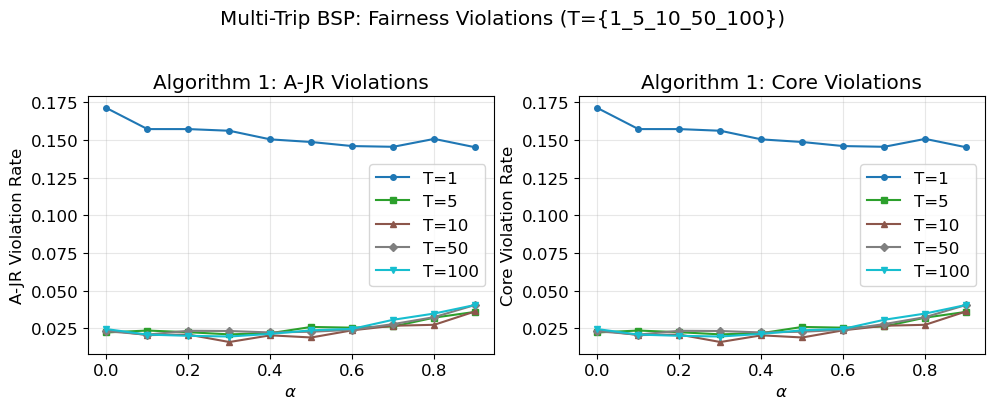

  Saved TBSP_alpha_comparison_T1_5_10_50_100.png

2. Multi-trip comparison: Benchmark violations vs alpa


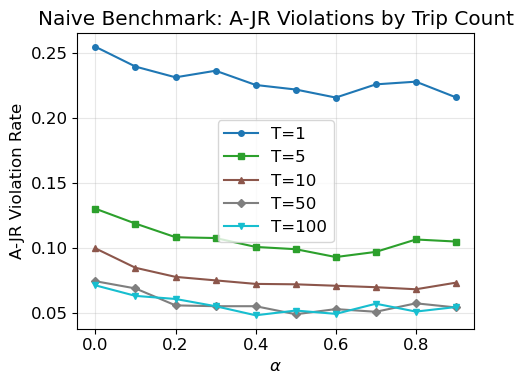

  Saved TBSP_benchmark_comparison_T1_5_10_50_100.png

3. Heatmaps (showing T = [1, 5, 10, 50, 100])


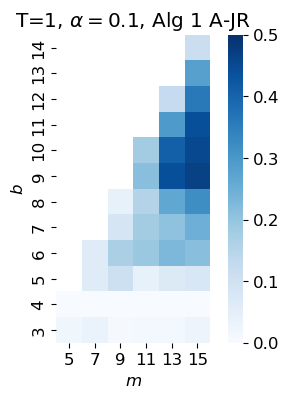

  Saved TBSP_heatmap_T1_a1.png


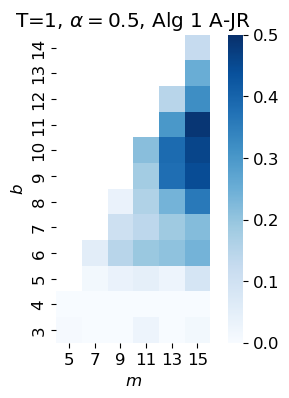

  Saved TBSP_heatmap_T1_a5.png


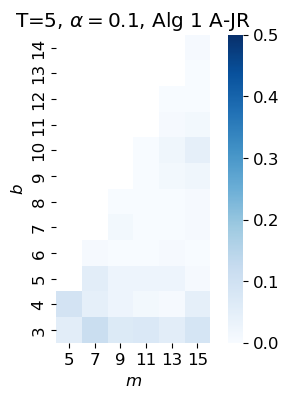

  Saved TBSP_heatmap_T5_a1.png


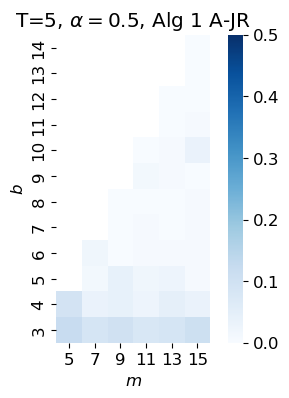

  Saved TBSP_heatmap_T5_a5.png


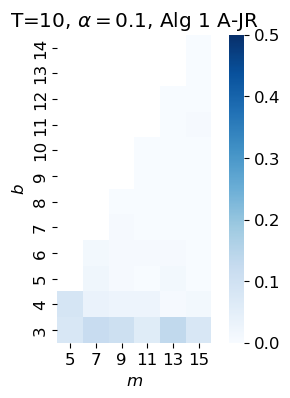

  Saved TBSP_heatmap_T10_a1.png


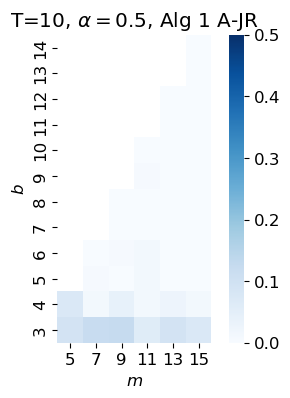

  Saved TBSP_heatmap_T10_a5.png


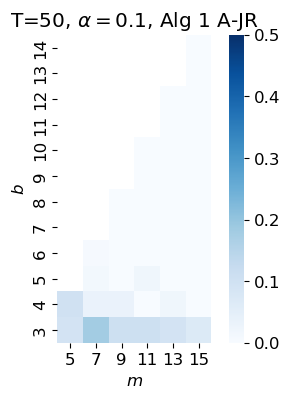

  Saved TBSP_heatmap_T50_a1.png


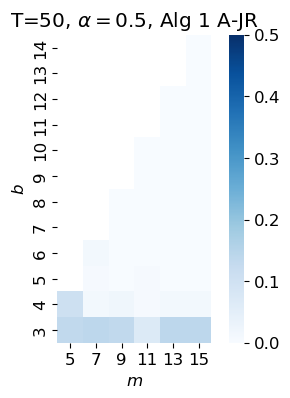

  Saved TBSP_heatmap_T50_a5.png


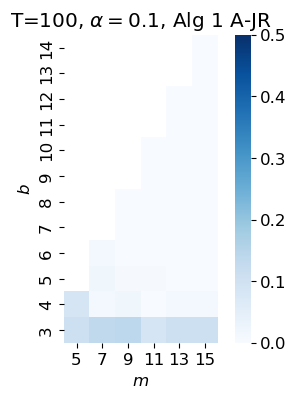

  Saved TBSP_heatmap_T100_a1.png


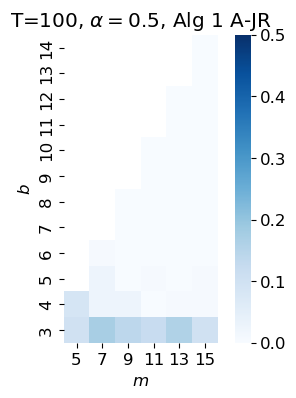

  Saved TBSP_heatmap_T100_a5.png

4. Broken-axis plots for T = [1, 10, 100]


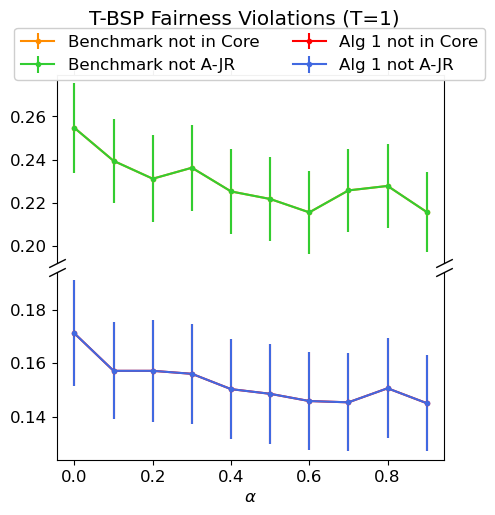

  Saved TBSP_broken_T1.png


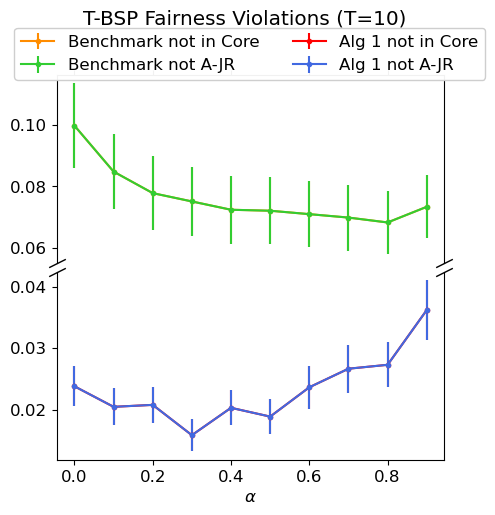

  Saved TBSP_broken_T10.png


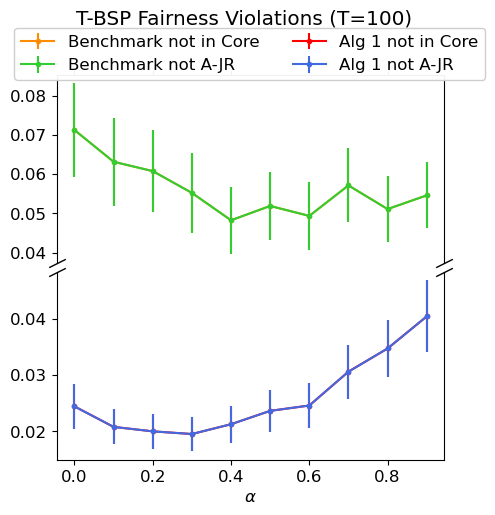

  Saved TBSP_broken_T100.png

All T-BSP figures generated.


In [16]:
print("=" * 10)
print("Generating T-BSP Figures")
print("=" * 10)

print("\n1. Multi-trip comparison: Alg 1 violations vs alpha")
draw_multitrip_alpha_comparison(results)

print("\n2. Multi-trip comparison: Benchmark violations vs alpa")
draw_multitrip_benchmark_comparison(results)

# Heatmaps to only plot first 5 T values to avoid hundreds of figures
T_for_heatmap = ALL_T[:5]
print(f"\n3. Heatmaps (showing T = {T_for_heatmap})")
for T in T_for_heatmap:
    for at in [1, 5]:
        draw_multitrip_heatmap(results, T, at)

T_to_plot = sorted(set([ALL_T[0], ALL_T[len(ALL_T)//2], ALL_T[-1]]))
print(f"\n4. Broken-axis plots for T = {T_to_plot}")
for T in T_to_plot:
    draw_broken_axis_comparison(results, T)

print("\nAll T-BSP figures generated.")